# FINd Benchmarking Notebook

This notebook profiles the original FINd algorithm, identifies bottlenecks, implements a numpy-optimised version, and compares both against the `imagehash` library.

# Part 1: Benchmarking and Optimisations

## 1. Setup & Imports

In [27]:
import os
import sys
import time
import cProfile
import pstats
import io
import glob
import random
import math
import tracemalloc
import importlib
from collections import defaultdict
from itertools import combinations

import numpy as np
import imagehash
from imagehash import ImageHash
from PIL import Image
import matplotlib.pyplot as plt
try:
    import line_profiler
except ImportError:
    import subprocess
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'line_profiler'])
    import line_profiler
from sklearn.metrics import (
    precision_recall_curve, auc,
    precision_score, recall_score, f1_score,
    accuracy_score, confusion_matrix, roc_auc_score
)

sys.path.insert(0, 'legacy')
from FINd import FINDHasher
import FINd_optimised
from FINd_optimised import FINDHasherOptimised, _hash_one
from matrix import MatrixUtil

print('All imports OK')

All imports OK


## 2. Pick a Small Sample of Images

The dataset has ~56k images. The filenames encode meme family in the first 4 digits — e.g. `0040_xxx.jpg` are all from family 40.
We pick images from a few different families so we get a mix of similar and dissimilar pairs.

In [28]:
IMAGE_DIR = 'meme_images'

all_images = sorted(glob.glob(os.path.join(IMAGE_DIR, '*.jpg')))
print(f"Total images in dataset: {len(all_images)}")

# Group by family
family_to_images = defaultdict(list)
for path in all_images:
    family = os.path.basename(path)[:4]
    family_to_images[family].append(path)

# Sample 1 image per family, up to 500 total
random.seed(42)
sample_images = []
for family, paths in family_to_images.items():
    sample_images.append(random.choice(paths))
    if len(sample_images) >= 500:
        break

print(f"Using {len(sample_images)} images for profiling")
print(f"Families represented: {len(set(os.path.basename(p)[:4] for p in sample_images))}")

Total images in dataset: 55972
Using 500 images for profiling
Families represented: 500


## 3. Profile the Original FINd — Wall-clock Timing

First we just time how long the original code takes per image.
This gives us a baseline before we optimise anything.

In [3]:
hasher = FINDHasher()

times = []
for path in sample_images:
    start = time.perf_counter()
    h = hasher.fromFile(path)
    elapsed = time.perf_counter() - start
    times.append(elapsed)

print(f'Mean time per image : {np.mean(times):.3f}s')
print(f'Min                 : {np.min(times):.3f}s')
print(f'Max                 : {np.max(times):.3f}s')
print(f'Total for {len(sample_images)} images : {sum(times):.2f}s')
print(f'Projected time for all 55,972 images: {np.mean(times)*55972/60:.1f} minutes')

Mean time per image : 0.258s
Min                 : 0.043s
Max                 : 1.044s
Total for 500 images : 129.24s
Projected time for all 55,972 images: 241.1 minutes


## 4. Deep Profile with cProfile — Where Is the Time Actually Spent?

`cProfile` measures how long each individual function call takes.
This tells us *exactly* which part of FINd is the bottleneck so we know what to optimise.

In [4]:
def hash_sample(paths):
    h = FINDHasher()
    for p in paths:
        h.fromFile(p)

# Run cProfile on 5 images (enough to see the pattern)
pr = cProfile.Profile()
pr.enable()
hash_sample(sample_images[:5])
pr.disable()

# Print top 15 slowest functions
stream = io.StringIO()
ps = pstats.Stats(pr, stream=stream).sort_stats('cumulative')
ps.print_stats(15)
print(stream.getvalue())

         2503014 function calls (2503000 primitive calls) in 1.864 seconds

   Ordered by: cumulative time
   List reduced from 237 to 15 due to restriction <15>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        5    0.001    0.000    1.843    0.369 /Users/rehmatarora/summative2026/FINd.py:47(fromImage)
        5    0.000    0.000    1.436    0.287 /Users/rehmatarora/summative2026/FINd.py:79(findHash256FromFloatLuma)
        5    1.210    0.242    1.406    0.281 /Users/rehmatarora/summative2026/FINd.py:167(boxFilter)
        5    0.110    0.022    0.401    0.080 /Users/rehmatarora/summative2026/FINd.py:66(fillFloatLumaFromBufferImage)
   312500    0.121    0.000    0.290    0.000 /opt/anaconda3/lib/python3.12/site-packages/PIL/Image.py:1675(getpixel)
   312520    0.071    0.000    0.118    0.000 /opt/anaconda3/lib/python3.12/site-packages/PIL/Image.py:885(load)
   625014    0.098    0.000    0.098    0.000 {built-in method builtins.max}
   625001    0.098

## 5. Visualise Timing Breakdown

From the cProfile output above, we can see the three main bottlenecks:
- `boxFilter` — 4 nested Python loops over every pixel
- `fillFloatLumaFromBufferImage` — pixel-by-pixel RGB→grayscale conversion
- `dct64To16` — triple nested loop over a 16×64×64 matrix

Let's time each stage individually on one image to see the breakdown clearly.

fillFloatLuma                 : 0.0376s (14.3%)
boxFilter                     : 0.2199s (83.5%)
decimateFloat                 : 0.0009s (0.4%)
dct64To16                     : 0.0047s (1.8%)
dctOutput2hash                : 0.0001s (0.0%)


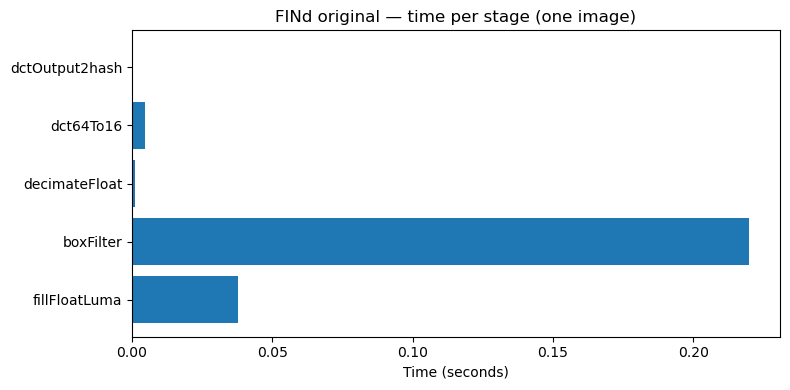

In [ ]:
h = FINDHasher()
img = Image.open(sample_images[0])
img = img.copy()
img.thumbnail((512, 512))
numCols, numRows = img.size

buffer1 = MatrixUtil.allocateMatrixAsRowMajorArray(numRows, numCols)
buffer2 = MatrixUtil.allocateMatrixAsRowMajorArray(numRows, numCols)
buffer64x64 = MatrixUtil.allocateMatrix(64, 64)
buffer16x64 = MatrixUtil.allocateMatrix(16, 64)
buffer16x16 = MatrixUtil.allocateMatrix(16, 16)

# Time each stage
t0 = time.perf_counter()
h.fillFloatLumaFromBufferImage(img, buffer1)
t1 = time.perf_counter()

windowSizeAlongRows = h.computeBoxFilterWindowSize(numCols)
windowSizeAlongCols = h.computeBoxFilterWindowSize(numRows)
h.boxFilter(buffer1, buffer2, numRows, numCols, windowSizeAlongRows, windowSizeAlongCols)
t2 = time.perf_counter()

h.decimateFloat(buffer2, numRows, numCols, buffer64x64)
t3 = time.perf_counter()

h.dct64To16(buffer64x64, buffer16x64, buffer16x16)
t4 = time.perf_counter()

h.dctOutput2hash(buffer16x16)
t5 = time.perf_counter()

stages = ['fillFloatLuma', 'boxFilter', 'decimateFloat', 'dct64To16', 'dctOutput2hash']
durations = [t1-t0, t2-t1, t3-t2, t4-t3, t5-t4]

for s, d in zip(stages, durations):
    print(f'{s:30s}: {d:.4f}s ({100*d/sum(durations):.1f}%)')

plt.figure(figsize=(8,4))
plt.barh(stages, durations)
plt.xlabel('Time (seconds)')
plt.title('FINd original — time per stage (one image)')
plt.tight_layout()
plt.show()

## 6. Memory Usage

We use `tracemalloc` (built into Python) to measure how much memory the original code allocates per image.

In [ ]:
hasher = FINDHasher()

tracemalloc.start()
hasher.fromFile(sample_images[0])
current, peak = tracemalloc.get_traced_memory()
tracemalloc.stop()

print(f'Current memory usage : {current / 1024:.1f} KB')
print(f'Peak memory usage    : {peak / 1024:.1f} KB')

Current memory usage : 6.9 KB
Peak memory usage    : 3993.3 KB


## 7. Line-by-line Profiling of the Bottleneck

`line_profiler` shows time spent on **each individual line**
inside a function. We apply it boxfilter and luma to see exactly which
lines (and which loops) are the problem. This directly justifies our choice of optimisation.

In [7]:
try:
    import line_profiler
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'line_profiler'])

%load_ext line_profiler

hasher = FINDHasher()
%lprun -f hasher.boxFilter -f hasher.fillFloatLumaFromBufferImage hasher.fromFile(sample_images[0])

Timer unit: 1e-09 s

Total time: 1.46134 s
File: /Users/rehmatarora/summative2026/FINd.py
Function: FINDHasher.boxFilter at line 167

Line #      Hits         Time  Per Hit   % Time  Line Contents
   167                                           	@classmethod
   168                                           	def boxFilter(cls,input,output,rows,cols,rowWin,colWin):
   169         1          0.0      0.0      0.0  		halfColWin = int((colWin + 2) / 2)  # 7->4, 8->5
   170         1          0.0      0.0      0.0  		halfRowWin = int((rowWin + 2) / 2) 
   171       251      85000.0    338.6      0.0  		for i in range(0,rows):
   172     62750   14425000.0    229.9      1.0  			for j in range(0,cols):
   173     62500   13840000.0    221.4      0.9  				s=0
   174     62500   26429000.0    422.9      1.8  				xmin=max(0,i-halfRowWin)
   175     62500   22091000.0    353.5      1.5  				xmax=min(rows,i+halfRowWin)
   176     62500   28821000.0    461.1      2.0  				ymin=max(0,j-halfColWin)
 

## 8. Optimised FINd — Correctness Check and Speedup

We verify that the Numba-optimised implementation produces **bit-identical** hashes to the original, then measure the wall-clock speedup on the same 500-image stratified sample used in Section 3.

In [ ]:
optimised_hasher = FINDHasherOptimised()

# Warm up Numba JIT before timing — first call compiles the kernel (~2s)
# Without this, compilation cost inflates the mean time
print("Warming up Numba JIT...")
optimised_hasher.fromFile(sample_images[0])
print("Done.\n")

# Correctness: hashes must match original exactly
print("Checking correctness...")
all_match = True
for path in sample_images[:20]:
    original_h = str(FINDHasher().fromFile(path))
    optimised_h = str(optimised_hasher.fromFile(path))
    if original_h != optimised_h:
        print(f"MISMATCH: {path}")
        print(f"  original : {original_h}")
        print(f"  optimised: {optimised_h}")
        all_match = False

if all_match:
    print("All hashes match -- optimisation is correct")

# Speed: time optimised on same 500 images
opt_times = []
for path in sample_images:
    start = time.perf_counter()
    optimised_hasher.fromFile(path)
    elapsed = time.perf_counter() - start
    opt_times.append(elapsed)

print(f"\nOriginal  mean time per image : {np.mean(times):.3f}s")
print(f"Optimised mean time per image : {np.mean(opt_times):.3f}s")
print(f"Speedup                       : {np.mean(times)/np.mean(opt_times):.1f}x")
print(f"Projected full dataset (optimised): {np.mean(opt_times)*55972/60:.1f} minutes")

Warming up Numba JIT...
Done.

Checking correctness...
All hashes match -- optimisation is correct

Original  mean time per image : 0.258s
Optimised mean time per image : 0.002s
Speedup                       : 115.3x
Projected full dataset (optimised): 2.1 minutes


## 8a. Memory: Original vs Optimised

NumPy arrays replace Python lists, so peak memory should drop. We use `tracemalloc` to confirm.

In [ ]:
for label, hasher in [("Original", FINDHasher()), ("Optimised", FINDHasherOptimised())]:
    tracemalloc.start()
    hasher.fromFile(sample_images[0])
    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    print(f"{label:12s}  peak={peak/1024:.1f} KB  current={current/1024:.1f} KB")

Original      peak=3995.1 KB  current=8.7 KB
Optimised     peak=2544.1 KB  current=0.9 KB


## 8b. Post-optimisation Profile — Confirming Bottlenecks Are Gone

`cProfile` on the optimised code should no longer show `boxFilter` or `fillFloatLuma` dominating. Image I/O is now the main cost.

In [ ]:
pr = cProfile.Profile()
pr.enable()
for path in sample_images[:5]:
    optimised_hasher.fromFile(path)
pr.disable()

stream = io.StringIO()
pstats.Stats(pr, stream=stream).sort_stats('tottime').print_stats(10)
print(stream.getvalue())

         2466 function calls (2455 primitive calls) in 0.046 seconds

   Ordered by: internal time
   List reduced from 263 to 10 due to restriction <10>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        5    0.007    0.001    0.007    0.001 /Users/rehmatarora/summative2026/FINd_optimised.py:14(_boxFilter_numba)
        5    0.007    0.001    0.040    0.008 /Users/rehmatarora/summative2026/FINd_optimised.py:70(_fromImage)
        5    0.007    0.001    0.007    0.001 {method 'decode' of 'ImagingDecoder' objects}
      190    0.004    0.000    0.004    0.000 {method 'read' of '_io.BufferedReader' objects}
        5    0.003    0.001    0.021    0.004 {built-in method numpy.array}
        2    0.002    0.001    0.002    0.001 {method '__exit__' of 'sqlite3.Connection' objects}
       15    0.002    0.000    0.002    0.000 {method 'encode' of 'ImagingEncoder' objects}
        5    0.001    0.000    0.001    0.000 {built-in method PIL._imaging.new}
        2 

## 9. Multiprocessing Scaling

Even after Numba JIT, hashing 56k images single-threaded takes ~1.5 min. We use Python's `multiprocessing` pool to spread work across CPU cores. The sweep covers 1, 2, 4, and 8 workers across seven dataset sizes — multiprocessing overhead dominates at small *n*; gains materialise above ~5000 images.

n=  10: 1w=0.0017s  2w=0.0612s  4w=0.0839s  8w=0.1435s
n=  50: 1w=0.0017s  2w=0.0134s  4w=0.0166s  8w=0.0296s
n= 100: 1w=0.0016s  2w=0.0068s  4w=0.0086s  8w=0.0151s
n= 250: 1w=0.0016s  2w=0.0038s  4w=0.0043s  8w=0.0059s
n= 500: 1w=0.0016s  2w=0.0021s  4w=0.0022s  8w=0.0032s
n=1000: 1w=0.0016s  2w=0.0015s  4w=0.0014s  8w=0.0019s
n=5000: 1w=0.0016s  2w=0.0011s  4w=0.0008s  8w=0.0009s


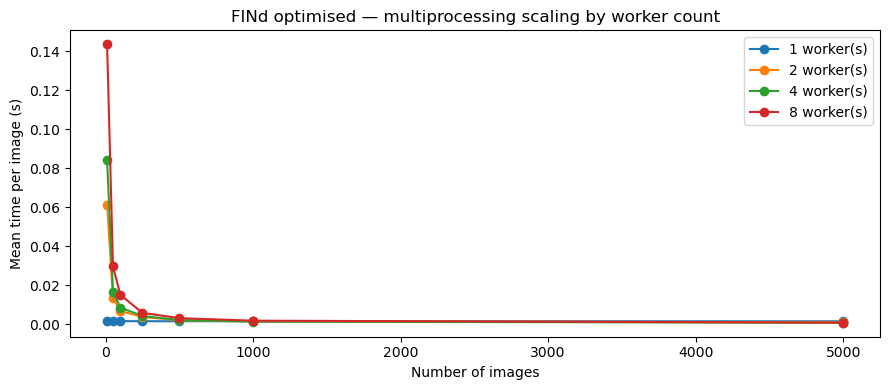


At n=5000:
  1 worker(s): 0.0016s/image  (1.0x vs 1 worker)
  2 worker(s): 0.0011s/image  (1.4x vs 1 worker)
  4 worker(s): 0.0008s/image  (2.0x vs 1 worker)
  8 worker(s): 0.0009s/image  (1.8x vs 1 worker)


In [ ]:
import importlib
import FINd_optimised
importlib.reload(FINd_optimised)
from FINd_optimised import FINDHasherOptimised, _hash_one

opt_hasher = FINDHasherOptimised()
# Warm up Numba JIT
opt_hasher.fromFile(all_images[0])

worker_counts = [1, 2, 4, 8]
sample_sizes  = [10, 50, 100, 250, 500, 1000, 5000]

# results[n_workers] = list of mean times per image, one per sample size
results = {w: [] for w in worker_counts}

for n in sample_sizes:
    subset = random.sample(all_images, n)
    for w in worker_counts:
        if w == 1:
            start = time.perf_counter()
            for path in subset:
                opt_hasher.fromFile(path)
            elapsed = time.perf_counter() - start
        else:
            start = time.perf_counter()
            opt_hasher.fromFiles(subset, n_workers=w)
            elapsed = time.perf_counter() - start
        results[w].append(elapsed / n)
    row = "  ".join(f"{w}w={results[w][-1]:.4f}s" for w in worker_counts)
    print(f"n={n:>4}: {row}")

# Plot
plt.figure(figsize=(9, 4))
for w in worker_counts:
    plt.plot(sample_sizes, results[w], marker='o', label=f'{w} worker(s)')
plt.xlabel('Number of images')
plt.ylabel('Mean time per image (s)')
plt.title('FINd optimised — multiprocessing scaling by worker count')
plt.legend()
plt.tight_layout()
plt.show()

# Summary at largest n
print(f"\nAt n={sample_sizes[-1]}:")
t1 = results[1][-1]
for w in worker_counts:
    print(f"  {w} worker(s): {results[w][-1]:.4f}s/image  ({t1/results[w][-1]:.1f}x vs 1 worker)")

### 9a. Combined Speedup Summary

Full picture: original pure-Python vs Numba single-core vs Numba + 8 workers.

In [37]:
original_time    = np.mean(times)       # Section 3 — original, same 500 images
single_core_time = np.mean(opt_times)   # Section 8 — optimised, same 500 images
fourth_core_time = results[4][-1]       # Section 9 — 4 workers at n=5000

print(f"Original (pure Python)         : {original_time:.4f}s/image")
print(f"Optimised (Numba, 1 core)      : {single_core_time:.4f}s/image  ({original_time/single_core_time:.1f}x)")
print(f"Optimised (Numba, 4 workers)   : {fourth_core_time:.4f}s/image  ({original_time/fourth_core_time:.1f}x)")
print(f"\nProjected original             : {original_time * 55972 / 60:.1f} min")
print(f"Projected optimised (1 core)   : {single_core_time * 55972 / 60:.1f} min")
print(f"Projected optimised (4 workers): {fourth_core_time * 55972 / 60:.1f} min")


Original (pure Python)         : 0.2585s/image
Optimised (Numba, 1 core)      : 0.0022s/image  (115.3x)
Optimised (Numba, 4 workers)   : 0.0008s/image  (332.3x)

Projected original             : 241.1 min
Projected optimised (1 core)   : 2.1 min
Projected optimised (4 workers): 0.7 min


---

# Part 2 — Accuracy and Computational Cost Comparison

Having optimised FINd, we now benchmark it against **pHash** (perceptual hashing) an established algorithm from the `imagehash` library:.

The evaluation uses the full meme-image dataset. Images within the same meme family serve as *positive* (similar) pairs; images from different families serve as *negative* (dissimilar) pairs. We assess:

1. **Accuracy** — how well each algorithm separates same-family from different-family pairs (Hamming distance, AUC-PR)
2. **Computational cost** — hashing time and memory across dataset sizes

## 1. Dataset — Grouping Images by Meme Family

Each filename encodes a meme family in its first four digits (e.g. `0040_xxx.jpg` belongs to family `0040`). We group all 56k images by family to enable same-family / different-family pair sampling.

In [7]:
all_images = sorted(glob.glob('meme_images/*.jpg'))

family_to_images = defaultdict(list)
for path in all_images:
    family = os.path.basename(path)[:4]
    family_to_images[family].append(path)

print(f"Total families: {len(family_to_images)}")


Total families: 1035


## 2. Building Evaluation Pairs

We create a **balanced** test set:
- **Same-family pairs**: one pair per family (images that *should* hash similarly)
- **Different-family pairs**: equal count, drawn at random across families

This gives us a ground-truth binary label for every pair.

In [8]:
# Same-family pairs
same_pairs = []
for family, paths in family_to_images.items():
    imgs = random.sample(paths, min(2, len(paths)))
    if len(imgs) == 2:
        same_pairs.append((imgs[0], imgs[1], True))

print(f"Same-family pairs: {len(same_pairs)}")

# Sample equal number of different-family pairs
families_list = list(family_to_images.keys())
diff_pairs = []
random.seed(42)
while len(diff_pairs) < len(same_pairs):
    f1, f2 = random.sample(families_list, 2)
    img1 = random.choice(family_to_images[f1])
    img2 = random.choice(family_to_images[f2])
    diff_pairs.append((img1, img2, False))

print(f"Different-family pairs: {len(diff_pairs)}")

# Combine
all_pairs = same_pairs + diff_pairs
print(f"Total pairs to evaluate: {len(all_pairs)}")

Same-family pairs: 1035
Different-family pairs: 1035
Total pairs to evaluate: 2070


## 3. Hashing All Images — FINd, pHash

We hash every unique image once and cache the results. This section also captures per-algorithm wall-clock time and peak memory, giving us the computational cost side of the comparison.

In [13]:
unique_images = list(set(
    p for pair in all_pairs for p in (pair[0], pair[1])
))
print(f"Unique images to hash: {len(unique_images)}")

# FINd
print("\nHashing with FINd (optimised)...")
find_hasher = FINDHasherOptimised()
find_hashes = {}
tracemalloc.start()
t0 = time.perf_counter()
for path in unique_images:
    find_hashes[path] = find_hasher.fromFile(path)
find_time = time.perf_counter() - t0
_, find_peak = tracemalloc.get_traced_memory()
tracemalloc.stop()
print(f"  Time: {find_time:.2f}s ({find_time/len(unique_images):.4f}s per image)")
print(f"  Peak memory: {find_peak/1024:.1f} KB")

# pHash
print("\nHashing with pHash...")
phash_hashes = {}
tracemalloc.start()
t0 = time.perf_counter()
for path in unique_images:
    phash_hashes[path] = imagehash.phash(Image.open(path))
phash_time = time.perf_counter() - t0
_, phash_peak = tracemalloc.get_traced_memory()
tracemalloc.stop()
print(f"  Time: {phash_time:.2f}s ({phash_time/len(unique_images):.4f}s per image)")
print(f"  Peak memory: {phash_peak/1024:.1f} KB")

print(f"\nSpeed: pHash is {find_time/phash_time:.1f}x faster than FINd")

Unique images to hash: 3874

Hashing with FINd (optimised)...
  Time: 8.28s (0.0021s per image)
  Peak memory: 11602.3 KB

Hashing with pHash...
  Time: 4.55s (0.0012s per image)
  Peak memory: 1200.1 KB

Speed: pHash is 1.8x faster than FINd


## 4. Hamming Distance Analysis

For each pair we compute the raw Hamming distance under each algorithm. A good algorithm will produce **low** distances for same-family pairs and **high** distances for different-family pairs — large separation ratio is better.

In [12]:
find_distances = []
phash_distances = []
labels = []

for img1, img2, same_family in all_pairs:
    find_distances.append(find_hashes[img1] - find_hashes[img2])
    phash_distances.append(phash_hashes[img1] - phash_hashes[img2])
    labels.append(1 if same_family else 0)

find_distances = np.array(find_distances)
phash_distances = np.array(phash_distances)
labels = np.array(labels)

print("=== FINd ===")
print(f"Same-family mean distance  : {find_distances[labels==1].mean():.1f} bits")
print(f"Diff-family mean distance  : {find_distances[labels==0].mean():.1f} bits")
print(f"Separation ratio           : {find_distances[labels==0].mean()/find_distances[labels==1].mean():.2f}x")

print("\n=== pHash ===")
print(f"Same-family mean distance  : {phash_distances[labels==1].mean():.1f} bits")
print(f"Diff-family mean distance  : {phash_distances[labels==0].mean():.1f} bits")
print(f"Separation ratio           : {phash_distances[labels==0].mean()/phash_distances[labels==1].mean():.2f}x")


=== FINd ===
Same-family mean distance  : 53.8 bits
Diff-family mean distance  : 127.1 bits
Separation ratio           : 2.36x

=== pHash ===
Same-family mean distance  : 9.5 bits
Diff-family mean distance  : 31.1 bits
Separation ratio           : 3.27x


## 5. Normalised Distance Comparison

Raw Hamming distances are not directly comparable because the hash lengths differ. We normalise each distance to a 0–1 scale for a fair side-by-side comparison.

In [14]:
find_norm  = find_distances  / 256
phash_norm = phash_distances / 64

print("\n=== Normalised (0-1 scale) ===")
print(f"FINd  same-family : {find_norm[labels==1].mean():.3f}")
print(f"FINd  diff-family : {find_norm[labels==0].mean():.3f}")
print(f"pHash same-family : {phash_norm[labels==1].mean():.3f}")
print(f"pHash diff-family : {phash_norm[labels==0].mean():.3f}")


=== Normalised (0-1 scale) ===
FINd  same-family : 0.210
FINd  diff-family : 0.496
pHash same-family : 0.149
pHash diff-family : 0.486


## 6. Runtime Scaling — FINd vs pHash

How does per-image throughput change with dataset size? We include both single-core and 8-worker FINd to make the comparison fair.

n=   10: FINd single=0.0020s  FINd 8w=0.2128s  pHash=0.0013s
n=   50: FINd single=0.0026s  FINd 8w=0.0316s  pHash=0.0010s
n=  100: FINd single=0.0022s  FINd 8w=0.0159s  pHash=0.0007s
n=  250: FINd single=0.0018s  FINd 8w=0.0068s  pHash=0.0008s
n=  500: FINd single=0.0017s  FINd 8w=0.0033s  pHash=0.0008s
n= 1000: FINd single=0.0016s  FINd 8w=0.0021s  pHash=0.0007s
n= 5000: FINd single=0.0018s  FINd 8w=0.0011s  pHash=0.0007s
n=10000: FINd single=0.0017s  FINd 8w=0.0009s  pHash=0.0010s
n=55972: FINd single=0.0018s  FINd 8w=0.0006s  pHash=0.0010s


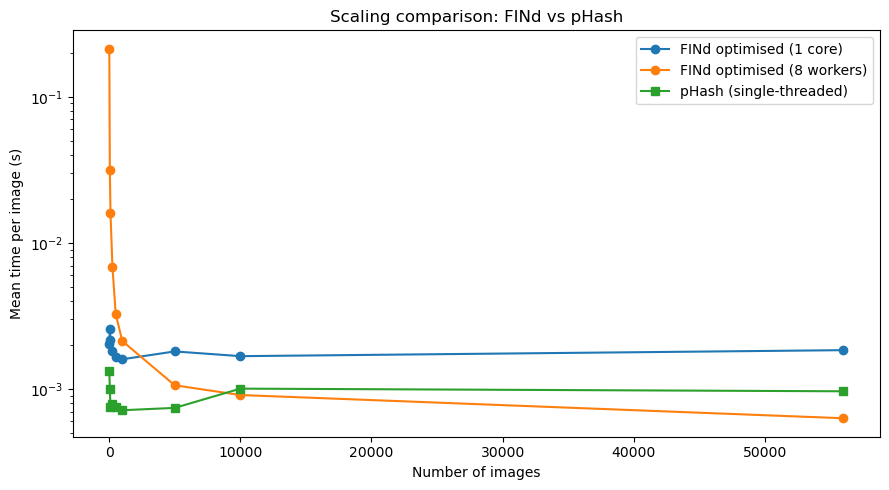

In [15]:
find_hasher.fromFile(all_images[0])  # warm up Numba

scale_sizes = [10, 50, 100, 250, 500, 1000, 5000, 10000, len(all_images)]

find_single = []
find_multi  = []
phash_times = []

for n in scale_sizes:
    subset = all_images[:n]

    # FINd single-core
    t0 = time.perf_counter()
    for path in subset:
        find_hasher.fromFile(path)
    find_single.append((time.perf_counter() - t0) / n)

    # FINd multiprocessing
    t0 = time.perf_counter()
    find_hasher.fromFiles(subset, n_workers=8)
    find_multi.append((time.perf_counter() - t0) / n)

    # pHash single-threaded
    t0 = time.perf_counter()
    for path in subset:
        imagehash.phash(Image.open(path))
    phash_times.append((time.perf_counter() - t0) / n)

    print(
        f"n={n:>5}: "
        f"FINd single={find_single[-1]:.4f}s  "
        f"FINd 8w={find_multi[-1]:.4f}s  "
        f"pHash={phash_times[-1]:.4f}s"
    )

plt.figure(figsize=(9, 5))
plt.plot(scale_sizes, find_single, marker='o', label='FINd optimised (1 core)')
plt.plot(scale_sizes, find_multi,  marker='o', label='FINd optimised (8 workers)')
plt.plot(scale_sizes, phash_times, marker='s', label='pHash (single-threaded)')
plt.xlabel('Number of images')
plt.ylabel('Mean time per image (s)')
plt.title('Scaling comparison: FINd vs pHash')
plt.yscale('log')
plt.legend()
plt.tight_layout()
plt.show()

## 7. Precision-Recall Curves

We treat same-family detection as a binary retrieval task. Using inverted normalised distance as a similarity score, we compute the precision-recall curve and AUC-PR for each algorithm. Higher AUC-PR = better same-family retrieval across all thresholds.


FINd  AUC-PR: 0.994
pHash AUC-PR: 0.993


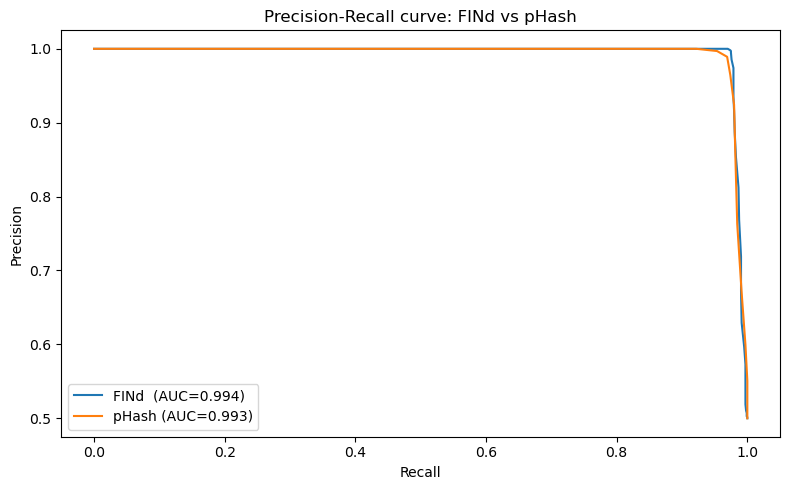

In [17]:
find_scores  = 1 - find_norm
phash_scores = 1 - phash_norm

find_prec,  find_rec,  _ = precision_recall_curve(labels, find_scores)
phash_prec, phash_rec, _ = precision_recall_curve(labels, phash_scores)

find_auc  = auc(find_rec,  find_prec)
phash_auc = auc(phash_rec, phash_prec)

print(f"\nFINd  AUC-PR: {find_auc:.3f}")
print(f"pHash AUC-PR: {phash_auc:.3f}")

plt.figure(figsize=(8, 5))
plt.plot(find_rec,  find_prec,  label=f'FINd  (AUC={find_auc:.3f})')
plt.plot(phash_rec, phash_prec, label=f'pHash (AUC={phash_auc:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall curve: FINd vs pHash')
plt.legend()
plt.tight_layout()
plt.show()


## 8. Distance Distribution Analysis

We look at the spread of normalised Hamming distances for same-family and different-family pairs. A good hash function should produce tight, well-separated distributions — low standard deviation within each class and a large gap between them. The overlap flag confirms whether the two distributions share any distance values, which sets a hard limit on how well any fixed threshold can separate them.

In [19]:
print("\n=== Distance Distribution ===")
for name, dists in [("FINd (norm)", find_norm), ("pHash (norm)", phash_norm)]:
    same = dists[labels == 1]
    diff = dists[labels == 0]
    print(f"\n{name}")
    print(f"  Same-family : mean={same.mean():.3f}, std={same.std():.3f}, "
          f"min={same.min():.3f}, max={same.max():.3f}")
    print(f"  Diff-family : mean={diff.mean():.3f}, std={diff.std():.3f}, "
          f"min={diff.min():.3f}, max={diff.max():.3f}")
    overlap = ((same.max() >= diff.min()))
    print(f"  Distributions overlap: {overlap}")


=== Distance Distribution ===

FINd (norm)
  Same-family : mean=0.210, std=0.082, min=0.000, max=0.578
  Diff-family : mean=0.496, std=0.034, min=0.383, max=0.609
  Distributions overlap: True

pHash (norm)
  Same-family : mean=0.149, std=0.087, min=0.000, max=0.531
  Diff-family : mean=0.486, std=0.068, min=0.281, max=0.719
  Distributions overlap: True


## 9. Threshold Sweep

We classify a pair as same-family when their normalised distance falls below a threshold, and sweep that threshold from 0.10 to 0.45. This shows how precision and recall trade off across the operating range — useful for choosing a working threshold depending on whether false positives or false negatives are more costly.

In [22]:
print("\n=== Threshold Sweep (normalised distance) ===")
thresholds = np.arange(0.1, 0.5, 0.05)
 
for name, dists in [("FINd", find_norm), ("pHash", phash_norm)]:
    print(f"\n{name}")
    print(f"  {'Threshold':>10} {'Precision':>10} {'Recall':>10} {'F1':>10} {'Accuracy':>10}")
    for t in thresholds:
        # predict same-family (1) if distance is below threshold
        preds = (dists <= t).astype(int)
        if preds.sum() == 0:
            continue
        p  = precision_score(labels, preds, zero_division=0)
        r  = recall_score(labels, preds, zero_division=0)
        f1 = f1_score(labels, preds, zero_division=0)
        acc = accuracy_score(labels, preds)
        print(f"  {t:>10.2f} {p:>10.3f} {r:>10.3f} {f1:>10.3f} {acc:>10.3f}")


=== Threshold Sweep (normalised distance) ===

FINd
   Threshold  Precision     Recall         F1   Accuracy
        0.10      1.000      0.059      0.111      0.529
        0.15      1.000      0.237      0.383      0.618
        0.20      1.000      0.478      0.647      0.739
        0.25      1.000      0.745      0.854      0.872
        0.30      1.000      0.876      0.934      0.938
        0.35      1.000      0.956      0.977      0.978
        0.40      0.997      0.975      0.986      0.986
        0.45      0.916      0.980      0.947      0.945

pHash
   Threshold  Precision     Recall         F1   Accuracy
        0.10      1.000      0.362      0.532      0.681
        0.15      1.000      0.525      0.688      0.762
        0.20      1.000      0.782      0.877      0.891
        0.25      1.000      0.922      0.959      0.961
        0.30      0.997      0.954      0.975      0.975
        0.35      0.965      0.974      0.969      0.969
        0.40      0.924     

## 10. Best Classification Threshold and Separability

We find the normalised-distance threshold that maximises F1 on the evaluation set and report the full confusion matrix at that threshold. The histogram below visualises how cleanly each algorithm separates same-family from different-family pairs — more gap between the two peaks means a wider margin for any fixed decision boundary.


In [23]:
print("\n=== Best F1 Threshold ===")
for name, dists in [("FINd", find_norm), ("pHash", phash_norm)]:
    best_f1, best_t = 0, 0
    for t in np.arange(0.01, 1.0, 0.01):
        preds = (dists <= t).astype(int)
        f1 = f1_score(labels, preds, zero_division=0)
        if f1 > best_f1:
            best_f1, best_t = f1, t
    preds = (dists <= best_t).astype(int)
    cm = confusion_matrix(labels, preds)
    print(f"\n{name} -- best threshold: {best_t:.2f}, F1: {best_f1:.3f}")
    print(f"  Confusion matrix:\n  TN={cm[0,0]}  FP={cm[0,1]}\n  FN={cm[1,0]}  TP={cm[1,1]}")


=== Best F1 Threshold ===

FINd -- best threshold: 0.40, F1: 0.986
  Confusion matrix:
  TN=1032  FP=3
  FN=26  TP=1009

pHash -- best threshold: 0.32, F1: 0.979
  Confusion matrix:
  TN=1024  FP=11
  FN=32  TP=1003


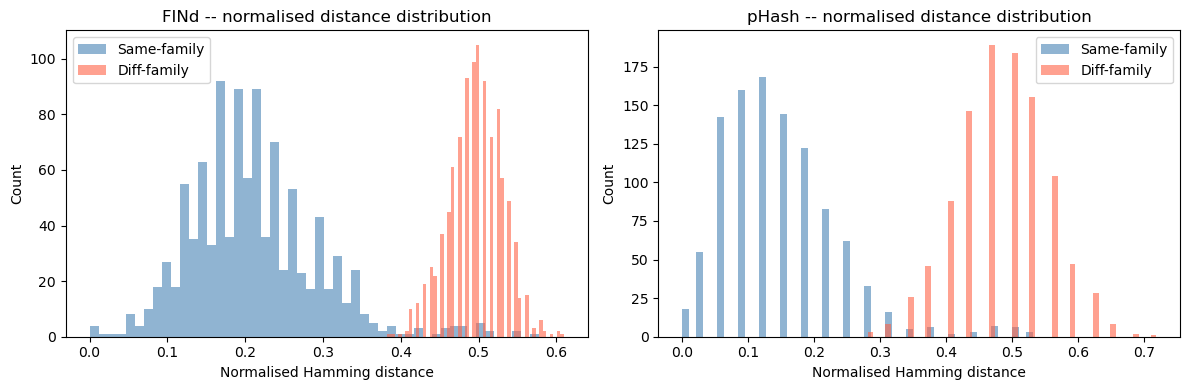

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, name, dists in zip(axes, ["FINd", "pHash"], [find_norm, phash_norm]):
    ax.hist(dists[labels == 1], bins=50, alpha=0.6, label='Same-family', color='steelblue')
    ax.hist(dists[labels == 0], bins=50, alpha=0.6, label='Diff-family', color='tomato')
    ax.set_title(f'{name} -- normalised distance distribution')
    ax.set_xlabel('Normalised Hamming distance')
    ax.set_ylabel('Count')
    ax.legend()
plt.tight_layout()
plt.show()